In [1]:
from pandas.core.indexes import period
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
#assumptions: 
    #calculating absolute individual stock price momentum (not factor momentum)
    #close price gives best represenation of stock price

[*********************100%***********************]  1 of 1 completed

Absolute Momentum (lagged ROC) for  TLX over a period of  60  days:
Date
2024-11-14          NaN
2024-11-15          NaN
2024-11-18          NaN
2024-11-19          NaN
2024-11-20          NaN
                ...    
2026-03-20     9.871788
2026-03-23     8.695650
2026-03-24    12.855376
2026-03-25     8.271605
2026-03-26    10.834370
Name: momentum, Length: 340, dtype: float64

 Graphs: 


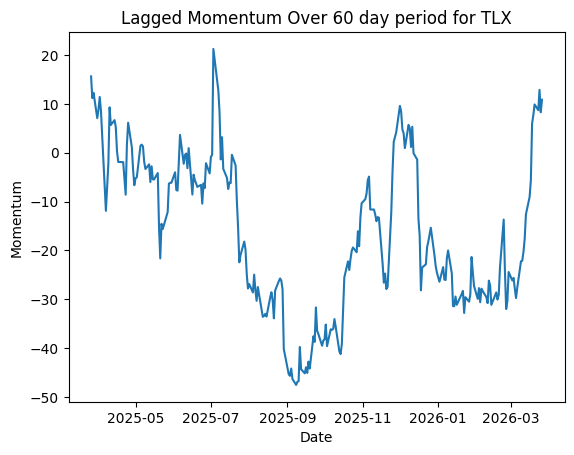

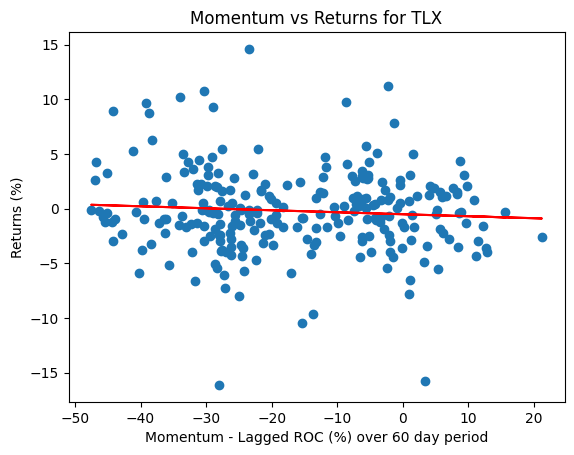

 
-0.01819 x - 0.5104

 
-0.04612 x - 0.4198


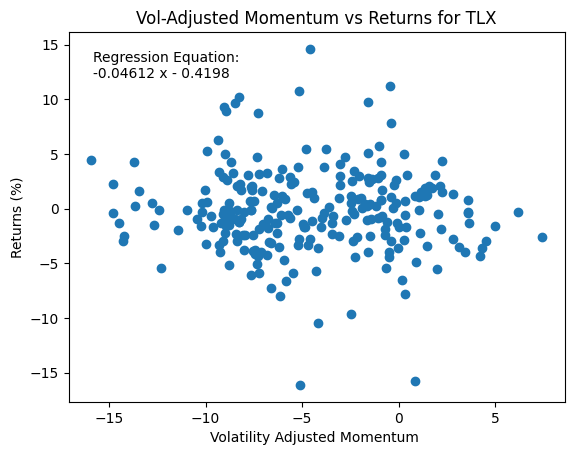

In [2]:
#generalized function for visualising momentum using ROC and factor exposure from regression for any stock
# using lagged ROC method for any inputted period (did 60 days for TLX)
ticker_symbol = input("Enter ticker symbol: ") # TLX for telix pharmaceuticals
p = int(input("Enter period for ROC (days):")) # 60 for 3 month momentum
def absmomentum(ticker_symbol, p):
    data = yf.download(ticker_symbol, period = "2y")
    price = data['Close']
    data['roc'] = price.pct_change(periods=p) * 100
    data['momentum'] = data['roc'].shift(1)
    data['momentum'] = data['momentum'].tail(252)
    print("Absolute Momentum (lagged ROC) for ", ticker_symbol,  "over a period of ", p, " days:")
    print(data['momentum'])
    
    #adjust to factor out general market momentum from ASX 200 NOT DONE

    data['returns'] = price.pct_change(1) * 100
    #adjust with volatility- momentum/volatility to account for reliabilty of momentum signal using rolling 20-day s.d. of returns as volatility measure
    data['vol_adj_m'] = data['momentum'] / data['returns'].rolling(20).std()

    data = data.dropna()
    print("\n Graphs: ")
    plt.plot(data.index, data['momentum'])
    plt.title("Lagged Momentum Over " + str(p) + " day period for " + ticker_symbol)
    plt.xlabel("Date")
    plt.ylabel("Momentum")
    plt.show()

    # scatter visualising relationship between momentum and returns
    factors = np.polyfit(data['momentum'], data['returns'], 1)
    regressioneq = np.poly1d(factors)
    plt.scatter(data['momentum'], data['returns'])
    plt.plot(data['momentum'], regressioneq(data['momentum']), color='red')
    plt.xlabel("Momentum - Lagged ROC (%) over " + str(p) + " day period")
    plt.ylabel("Returns (%)")
    plt.title("Momentum vs Returns for " + ticker_symbol)
    plt.show()
    print("This is regression equation for momentum vs returns (unadjusted):")
    print(regressioneq)
    print("")
    
    #volatility adjusted momentum scatter vs returns plot
    adjfactors = np.polyfit(data['vol_adj_m'], data['returns'], 1)
    adjregressioneq = np.poly1d(adjfactors)
    plt.scatter(data['vol_adj_m'], data['returns'])
    plt.xlabel("Volatility Adjusted Momentum ")
    plt.ylabel("Returns (%)")
    plt.title("Vol-Adjusted Momentum vs Returns for " + ticker_symbol)
    plt.text(0.05, 0.95, "Regression Equation: " + str(adjregressioneq), transform=plt.gca().transAxes, fontsize=10, verticalalignment='top')
    print("This is regression equation for volatility adjusted momentum vs returns:")
    print(adjregressioneq)
    plt.show()

#just input TLX for telix pharmaceuticals and put period as 60 to display data
absmomentum(ticker_symbol, p)
    